# Ultraspherical Spectral Methods: a Toolbox

> **Big Idea.** Physical-space Chebyshev collocation is conceptually
> simple but produces dense, ill-conditioned matrices: $\kappa(D_N^k)$
> grows like $N^{2k}$. The *ultraspherical* method of Olver and Townsend
> (2013) cures both problems by writing each derivative in its own
> basis: $u$ in the Chebyshev basis $T_k$, $u'$ in the
> ultraspherical basis $C_k^{(1)}$, $u''$ in $C_k^{(2)}$, and so on.
> The result is a **sparse, well-conditioned, almost-banded** linear
> system. The price is a few extra operators that translate between
> bases. This notebook builds those operators from scratch and uses
> them to solve two boundary value problems plus a simple adaptive
> QR solve.

The ultraspherical (Gegenbauer) polynomials $\{C_k^{(\lambda)}\}_{k\ge 0}$
are a one-parameter family. Two members already have names:
$T_k$ are essentially $C_k^{(0)}$, and the second-kind Chebyshev
polynomials $U_k$ are exactly $C_k^{(1)}$. We will only need this
$\lambda = 1$ family in this notebook (because we only do first-order
problems), but the higher-order generalisation lurks in the names of
the operators below: $\mathcal{D}_0,\ \mathcal{S}_0,\ \mathcal{M}_0$ all
carry a subscript that will become $\lambda - 1$ for an order-$\lambda$
derivative.

We will implement, from scratch:

1. The differentiation operator $\mathcal{D}_0 : T_k \to C_{k-1}^{(1)} = U_{k-1}$.
2. The conversion operator $\mathcal{S}_0 : T_k \to C_k^{(1)} = U_k$.
3. The multiplication operator $\mathcal{M}_0[a]$ acting on $U$-coefficients.
4. A pair of worked BVPs with $a(x) = 1$ and $a(x) = 1 + x$.
5. An adaptive QR sweep that picks $N$ on the fly.

We assume the basics from the [Chebyshev toolbox](chebyshev-toolbox.ipynb):
type-2 nodes, the DCT-based `polyfit`/`polyval` pair, the second
barycentric formula, and Chebyshev polynomials $T_k$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct

plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12

## 1. Two bases: $T_k$ and $C_k^{(1)} = U_k$

We use two members of the ultraspherical family side by side.

The **Chebyshev polynomials of the first kind** $T_k$ expand the
unknown $u$. The **first ultraspherical family** $C_k^{(1)}$, more
familiar as the **Chebyshev polynomials of the second kind** $U_k$,
is where we put $u'$. They are defined by
$$
U_k(\cos\theta) = \frac{\sin((k+1)\theta)}{\sin\theta}, \qquad k = 0, 1, 2, \ldots
$$
or equivalently by the same three-term recurrence as $T_k$,
$$
U_{k+1}(x) = 2x\,U_k(x) - U_{k-1}(x), \qquad U_0 = 1,\quad U_1 = 2x.
$$
We will need three identities, all classical:

1. **Differentiation lifts $T \to U$.** For $k \ge 1$,
   $$T_k'(x) = k\, U_{k-1}(x).$$

2. **The two bases are nearly the same.** $T_0 = U_0$, $T_1 = \tfrac{1}{2} U_1$,
   and for $k \ge 2$,
   $$T_k = \tfrac{1}{2}(U_k - U_{k-2}).$$

3. **Multiplication by $x$ is tridiagonal in the $U$ basis.** From the
   recurrence,
   $$x\,U_k(x) = \tfrac{1}{2}(U_{k+1}(x) + U_{k-1}(x)).$$

Every operator in this notebook is built from these three identities.
For higher-order BVPs the same identities recur with $C^{(\lambda)}$
in place of $U = C^{(1)}$.

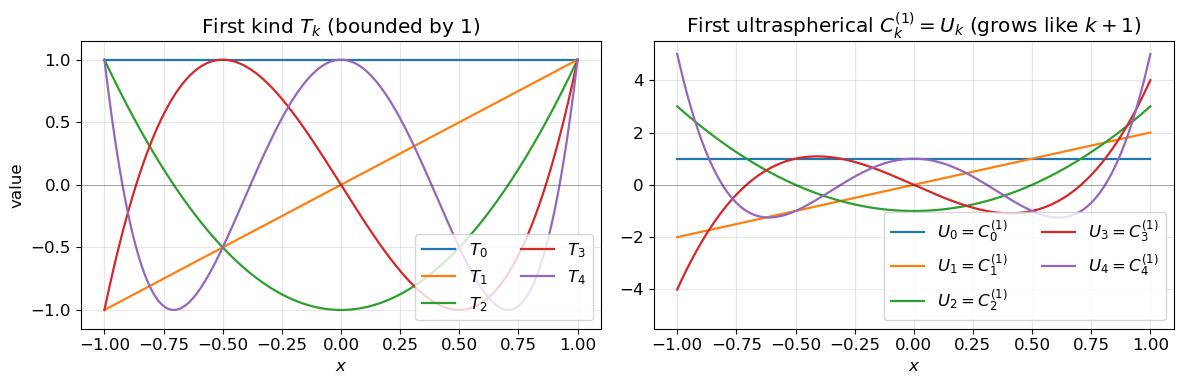

In [2]:
# Visualise T_k and U_k = C_k^{(1)} side by side.
xx = np.linspace(-1, 1, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k in range(5):
    Tk = np.cos(k * np.arccos(xx))
    if k == 0:
        Uk = np.ones_like(xx)
    elif k == 1:
        Uk = 2 * xx
    else:
        Um1 = np.ones_like(xx); U = 2 * xx
        for j in range(2, k + 1):
            Um1, U = U, 2 * xx * U - Um1
        Uk = U
    axes[0].plot(xx, Tk, lw=1.6, label=f'$T_{k}$')
    axes[1].plot(xx, Uk, lw=1.6, label=f'$U_{k} = C_{k}^{{(1)}}$')

axes[0].set_title('First kind $T_k$ (bounded by 1)')
axes[0].set_ylim(-1.15, 1.15)
axes[1].set_title('First ultraspherical $C_k^{(1)} = U_k$ (grows like $k+1$)')
axes[1].set_ylim(-5.5, 5.5)
for ax in axes:
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    ax.set_xlabel('$x$')
    ax.legend(loc='lower right', ncol=2); ax.grid(alpha=0.3)
axes[0].set_ylabel('value')
plt.tight_layout(); plt.show()

$T_k$ is bounded by $1$ on $[-1, 1]$. $U_k$ is unbounded near the
endpoints (it reaches $\pm(k+1)$ at $x = \pm 1$). The two coexist in
the discretisation: $u$ lives in $T$-space, $u'$ lives in $U$-space.
The ultraspherical bookkeeping translates between them.

## 2. Toolbox primitives

We reuse the value-coefficient transforms from the
[Chebyshev toolbox](chebyshev-toolbox.ipynb): `chebpts`, `polyfit`,
`polyval`, and the second-barycentric `barycentric` for evaluating a
$T$-expansion at arbitrary points. They are the only DCT-based pieces
we need: everything else in this notebook acts directly on coefficient
vectors.

In [3]:
def chebpts(n):
    # Type-2 Chebyshev points on [-1, 1], increasing order.
    if n == 1:
        return np.array([0.0])
    return np.sin(np.pi * np.arange(-n + 1, n, 2) / (2.0 * (n - 1)))


def polyfit(f):
    # Values at type-2 nodes (-1 -> +1) -> Chebyshev coefficients.
    f = np.asarray(f, dtype=float)
    n = f.size
    if n == 1:
        return f.copy()
    c = dct(f[::-1], type=1) / (n - 1)
    c[0] *= 0.5
    c[-1] *= 0.5
    return c


def polyval(c):
    # Chebyshev coefficients -> values at type-2 nodes.
    c = np.asarray(c, dtype=float)
    n = c.size
    if n == 1:
        return c.copy()
    a = c.copy()
    a[1:-1] *= 0.5
    return dct(a, type=1)[::-1]


def bary_weights(n):
    # Barycentric weights for type-2 nodes.
    if n == 1:
        return np.array([1.0])
    w = np.ones(n)
    w[-2::-2] = -1.0
    w[0] *= 0.5
    w[-1] *= 0.5
    return w


def barycentric(y, x, fvals, w=None):
    # Evaluate the polynomial that interpolates (x, fvals) at points y.
    if w is None:
        w = bary_weights(x.size)
    y = np.atleast_1d(np.asarray(y, dtype=float))
    diff = y[:, None] - x[None, :]
    with np.errstate(divide='ignore', invalid='ignore'):
        wdiff = w[None, :] / diff
        out = (wdiff @ fvals) / wdiff.sum(axis=1)
    hit_rows, hit_cols = np.where(diff == 0)
    out[hit_rows] = fvals[hit_cols]
    return out


def cheb_eval(c, y):
    # Evaluate sum c_k T_k(x) at arbitrary points y, using the toolbox
    # primitives: coefficients -> values at type-2 nodes -> barycentric.
    n = c.size
    return barycentric(y, chebpts(n), polyval(c))

## 3. The differentiation operator $\mathcal{D}_0$

If $u(x) = \sum_{k=0}^{N} c_k T_k(x)$, then differentiating term by
term and using $T_k' = k\, U_{k-1}$ gives
$$
u'(x) = \sum_{k=1}^{N} k\, c_k\, U_{k-1}(x).
$$
So $u'$ is naturally expressed in the $U$ basis, with $N$ coefficients
obtained from the $N+1$ $T$-coefficients of $u$. The operator is therefore
*rectangular*:
$$
\mathcal{D}_0 \in \mathbb{R}^{N \times (N+1)},
\qquad (\mathcal{D}_0\,\mathbf{c})_{k-1} = k\, c_k, \quad k = 1, \ldots, N.
$$
Concretely,
$$
\mathcal{D}_0 = \begin{pmatrix}
0 & 1 & 0 & 0 & \cdots & 0 \\
0 & 0 & 2 & 0 & \cdots & 0 \\
0 & 0 & 0 & 3 & \cdots & 0 \\
\vdots & & & & \ddots & \vdots \\
0 & 0 & 0 & 0 & \cdots & N
\end{pmatrix},
$$
a single super-diagonal of strictly increasing entries. The shape
mismatch (one fewer row than column) reflects the fact that the
highest mode $T_N$ has nowhere to go in a length-$N+1$ $U$-expansion;
we drop it. The free row will get used by the boundary condition.

In [4]:
def D0(N):
    # T-coefficients (length N+1) -> U-coefficients (length N).
    D = np.zeros((N, N + 1))
    for k in range(1, N + 1):
        D[k - 1, k] = k
    return D


# Sanity check: T_3' = 3 U_2.
N = 8
c = np.zeros(N + 1); c[3] = 1.0
print("D0 @ e_3 =", D0(N) @ c)            # expect 3 in slot 2

# A second check: 1 + 2 T_1 + T_2 differentiates to 2 U_0 + 2 U_1.
c = np.array([1.0, 2.0, 1.0] + [0.0] * (N - 2))
print("D0 @ (1, 2, 1, 0, ...) =", D0(N) @ c)
print("D0 shape at N = 8:", D0(8).shape)

D0 @ e_3 = [0. 0. 3. 0. 0. 0. 0. 0.]
D0 @ (1, 2, 1, 0, ...) = [2. 2. 0. 0. 0. 0. 0. 0.]
D0 shape at N = 8: (8, 9)


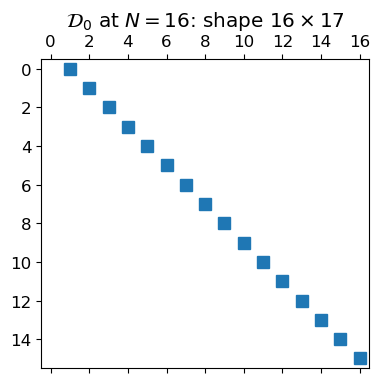

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.spy(D0(16), markersize=9)
ax.set_title(r'$\mathcal{D}_0$ at $N = 16$: shape $16 \times 17$')
plt.tight_layout(); plt.show()

## 4. The conversion operator $\mathcal{S}_0$

The right-hand side of a BVP is given as a $T$-expansion, but the
equation $u'(x) = f(x)$ asks us to compare $u'$ in the $U$ basis with
$f$ in the $T$ basis. We need a bridge.

From the identities $T_0 = U_0$, $T_1 = \tfrac{1}{2} U_1$, and
$T_k = \tfrac{1}{2}(U_k - U_{k-2})$ for $k \ge 2$, the conversion
$T \to U$ acts on a length-$(N+1)$ coefficient vector and returns
a length-$N$ vector (we cannot represent $U_N$ from a truncated
$T$-expansion). So $\mathcal{S}_0$ is also $N \times (N+1)$:
$$
\mathcal{S}_0 = \begin{pmatrix}
1 & 0 & -\tfrac{1}{2} & 0 & 0 & \cdots & 0 \\
0 & \tfrac{1}{2} & 0 & -\tfrac{1}{2} & 0 & \cdots & 0 \\
0 & 0 & \tfrac{1}{2} & 0 & -\tfrac{1}{2} & \cdots & 0 \\
\vdots & & & & \ddots & & \vdots
\end{pmatrix}.
$$
A main diagonal at $\tfrac{1}{2}$ (with $\mathcal{S}_0[0,0] = 1$) and
a second super-diagonal at $-\tfrac{1}{2}$. Bandwidth two.

In [6]:
def S0(N):
    # T-coefficients (length N+1) -> U-coefficients (length N).
    S = np.zeros((N, N + 1))
    if N >= 1:
        S[0, 0] = 1.0
    if N >= 1 and N + 1 > 2:
        S[0, 2] = -0.5
    for k in range(1, N):
        S[k, k] = 0.5
        if k + 2 <= N:
            S[k, k + 2] = -0.5
    return S


# Sanity check: T_0 + T_2 in T-coords becomes (1/2) U_0 + (1/2) U_2 in U-coords.
N = 6
c = np.array([1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0])
print("S0 @ (1, 0, 1, 0, ...) =", S0(N) @ c)
# T_3 = (1/2)(U_3 - U_1)
c = np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0])
print("S0 @ e_3 =", S0(N) @ c)
print("S0 shape at N = 6:", S0(6).shape)

S0 @ (1, 0, 1, 0, ...) = [0.5 0.  0.5 0.  0.  0. ]
S0 @ e_3 = [ 0.  -0.5  0.   0.5  0.   0. ]
S0 shape at N = 6: (6, 7)


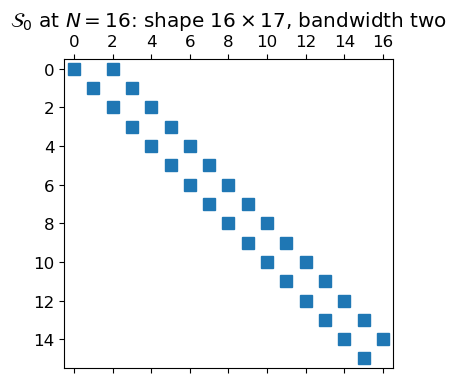

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.spy(S0(16), markersize=9)
ax.set_title(r'$\mathcal{S}_0$ at $N = 16$: shape $16 \times 17$, bandwidth two')
plt.tight_layout(); plt.show()

## 5. The boundary row

A Dirichlet condition $u(-1) = \alpha$ is one linear constraint on the
$T$-coefficients of $u$. Since $T_k(-1) = (-1)^k$,
$$
u(-1) = \sum_{k=0}^{N} (-1)^k c_k = \mathbf{b}^{\top} \mathbf{c},
\qquad
\mathbf{b} = (1, -1, 1, -1, \ldots, (-1)^N).
$$
This is a single dense row of length $N+1$, exactly the right size to
slot in above $\mathcal{D}_0$ and produce a square system. The
right-end condition $u(1) = \beta$ would give the row of all ones
because $T_k(1) = 1$.

In [8]:
def bc_left(N):
    # b @ c = u(-1) since T_k(-1) = (-1)^k.
    return (-1.0) ** np.arange(N + 1)

def bc_right(N):
    # b @ c = u(+1) since T_k(1) = 1.
    return np.ones(N + 1)

print("bc_left(6) =", bc_left(6))
print("bc_right(6) =", bc_right(6))

bc_left(6) = [ 1. -1.  1. -1.  1. -1.  1.]
bc_right(6) = [1. 1. 1. 1. 1. 1. 1.]


## 6. Worked example: $u'(x) = f(x),\ u(-1) = \alpha$

We have everything we need for the constant-coefficient case
$a(x) \equiv 1$:

- One row enforcing the boundary condition: $\mathbf{b}^\top \mathbf{c} = \alpha$.
- $N$ equations $u' = f$, asking that the $U$-coefficients of $u'$
  agree with those of $f$.

Stacking the boundary row above $\mathcal{D}_0$ produces a square
$(N+1) \times (N+1)$ system:

$$
\underbrace{\begin{pmatrix} \mathbf{b}^\top \\ \mathcal{D}_0 \end{pmatrix}}_{\mathcal{L}}
\,\mathbf{c} =
\begin{pmatrix} \alpha \\ \mathcal{S}_0\,\mathbf{f}_T \end{pmatrix},
$$

where $\mathbf{f}_T$ is the Chebyshev expansion of $f$ at length $N+1$.
The structure is one dense top row sitting on a banded interior.

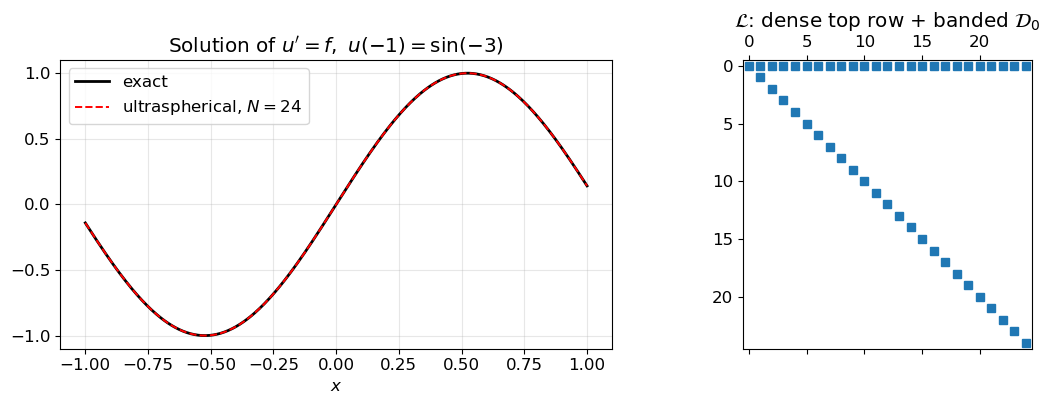

sup-norm error at N = 24: 9.99e-16


In [9]:
def assemble_simple(N, f, alpha):
    # System for u'(x) = f(x), u(-1) = alpha at length N+1.
    f_T = polyfit(f(chebpts(N + 1)))
    L = np.vstack([bc_left(N), D0(N)])
    rhs = np.concatenate([[alpha], S0(N) @ f_T])
    return L, rhs


# Manufactured solution: u(x) = sin(3x), so u'(x) = 3 cos(3x).
u_exact = lambda x: np.sin(3 * x)
f       = lambda x: 3 * np.cos(3 * x)
alpha   = u_exact(-1)

N = 24
L, rhs = assemble_simple(N, f, alpha)
c = np.linalg.solve(L, rhs)

xx = np.linspace(-1, 1, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(xx, u_exact(xx), 'k-', lw=2, label='exact')
axes[0].plot(xx, cheb_eval(c, xx), 'r--', lw=1.4, label=f'ultraspherical, $N = {N}$')
axes[0].set_xlabel('$x$'); axes[0].set_title("Solution of $u' = f,\\ u(-1) = \\sin(-3)$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].spy(np.abs(L) > 1e-14, markersize=6)
axes[1].set_title(r'$\mathcal{L}$: dense top row + banded $\mathcal{D}_0$')
plt.tight_layout(); plt.show()

print(f"sup-norm error at N = {N}: {np.max(np.abs(cheb_eval(c, xx) - u_exact(xx))):.2e}")

### Spectral convergence

Spectral methods earn their name when the data is smooth: a $C^\infty$
right-hand side gives geometric coefficient decay, and the BVP solve
inherits that rate.

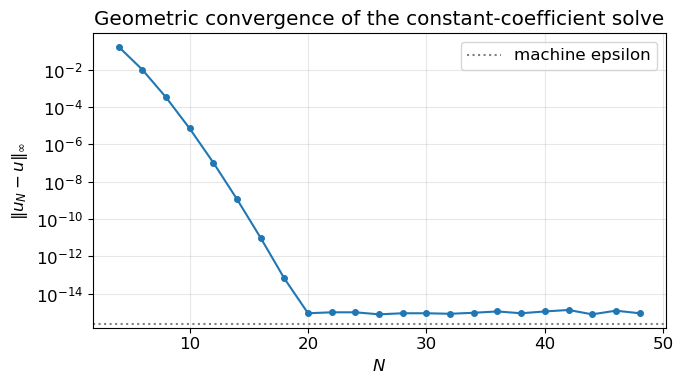

In [10]:
Ns = np.arange(4, 49, 2)
errs = []
for N in Ns:
    L, rhs = assemble_simple(N, f, alpha)
    c = np.linalg.solve(L, rhs)
    errs.append(np.max(np.abs(cheb_eval(c, xx) - u_exact(xx))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(Ns, errs, 'o-', ms=4)
ax.axhline(np.finfo(float).eps, color='gray', ls=':', label='machine epsilon')
ax.set_xlabel('$N$'); ax.set_ylabel(r'$\|u_N - u\|_\infty$')
ax.set_title('Geometric convergence of the constant-coefficient solve')
ax.legend(); ax.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

The error halves the digit count every few extra modes until it
flatlines at machine precision. The flat region is the floor of
double-precision arithmetic, not a property of the method.

## 7. Variable coefficients: the multiplication operator $\mathcal{M}_0[a]$

The constant-coefficient case never used the $U$-basis multiplication
structure, because $a \equiv 1$ acts as the identity. To handle a
genuine variable coefficient like $a(x) = 1 + x$, we need an operator
$\mathcal{M}_0[a]$ that takes $U$-coefficients of any function $g$ and
returns $U$-coefficients of $a\,g$. Since the $U$-coefficient vector
of $u'$ has length $N$, this operator is $N \times N$.

The base case is multiplication by $x$. From $x\,U_k = \tfrac{1}{2}(U_{k+1} + U_{k-1})$
(with $U_{-1} = 0$),
$$
\mathcal{M}_0[x] = \frac{1}{2}\begin{pmatrix}
0 & 1 & & & \\
1 & 0 & 1 & & \\
& 1 & 0 & 1 & \\
& & \ddots & \ddots & \ddots
\end{pmatrix},
$$
a *symmetric tridiagonal* matrix.

For a general $a(x) = \sum_{k=0}^{d} a_k\, T_k(x)$, the matrices
$\mathcal{M}_0[T_k]$ satisfy the same three-term recurrence as the
polynomials themselves:
$$
\mathcal{M}_0[T_0] = I, \qquad
\mathcal{M}_0[T_1] = \mathcal{M}_0[x],
$$
$$
\mathcal{M}_0[T_{k+1}] = 2\,\mathcal{M}_0[x]\,\mathcal{M}_0[T_k] - \mathcal{M}_0[T_{k-1}].
$$
Then $\mathcal{M}_0[a] = \sum_k a_k \mathcal{M}_0[T_k]$.

The bandwidth of $\mathcal{M}_0[T_k]$ is exactly $k$ (each application
of $\mathcal{M}_0[x]$ widens the band by one). So a coefficient
function $a$ with a *short* Chebyshev expansion produces a *narrow*
multiplication operator. Linear $a(x) = 1 + x$ gives a tridiagonal,
quadratic $a$ gives bandwidth two, and so on.

In [11]:
def M0_x(N):
    # Multiplication by x in the U_k basis: (x U_k) = (U_{k+1} + U_{k-1}) / 2.
    # Acts on U-coefficient vectors of length N, so size N x N.
    M = np.zeros((N, N))
    for k in range(N):
        if k - 1 >= 0:
            M[k, k - 1] = 0.5
        if k + 1 < N:
            M[k, k + 1] = 0.5
    return M


def M0_from_T(a_T, N):
    # Build M_0[a] (size N x N) from T-coefficients a_T using the polynomial
    # recurrence M[T_{k+1}] = 2 Mx M[T_k] - M[T_{k-1}].
    Mx = M0_x(N)
    I = np.eye(N)
    out = a_T[0] * I
    if a_T.size >= 2:
        out = out + a_T[1] * Mx
    M_prev, M_curr = I, Mx
    for k in range(1, a_T.size - 1):
        M_next = 2.0 * Mx @ M_curr - M_prev
        out = out + a_T[k + 1] * M_next
        M_prev, M_curr = M_curr, M_next
    return out

In [12]:
# Sanity check: for a(x) = 1 + x, M_0[a] should equal I + Mx.
N = 24
a_T = np.zeros(N + 1); a_T[0] = 1.0; a_T[1] = 1.0
Ma = M0_from_T(a_T, N)
print(f"||M0[1+x] - (I + M0[x])||_F = {np.linalg.norm(Ma - (np.eye(N) + M0_x(N))):.2e}")

# Multiplication of u'(x) by (1 + x). Take u(x) = exp(x), so u'(x) = exp(x).
# Then (1 + x) exp(x) computed two ways:
x = chebpts(N + 1)
up_U_direct = D0(N) @ polyfit(np.exp(x))                 # U-coefs of u', length N
prod_U_via_M = Ma @ up_U_direct                          # M_0[1+x] times that, length N
prod_U_direct = S0(N) @ polyfit((1 + x) * np.exp(x))     # T-coefs of (1+x)e^x, then S_0
print(f"M0[1+x] (D0 c) vs S0 polyfit((1+x) exp(x)): "
      f"{np.max(np.abs(prod_U_via_M - prod_U_direct)):.2e}")

||M0[1+x] - (I + M0[x])||_F = 0.00e+00
M0[1+x] (D0 c) vs S0 polyfit((1+x) exp(x)): 1.70e-15


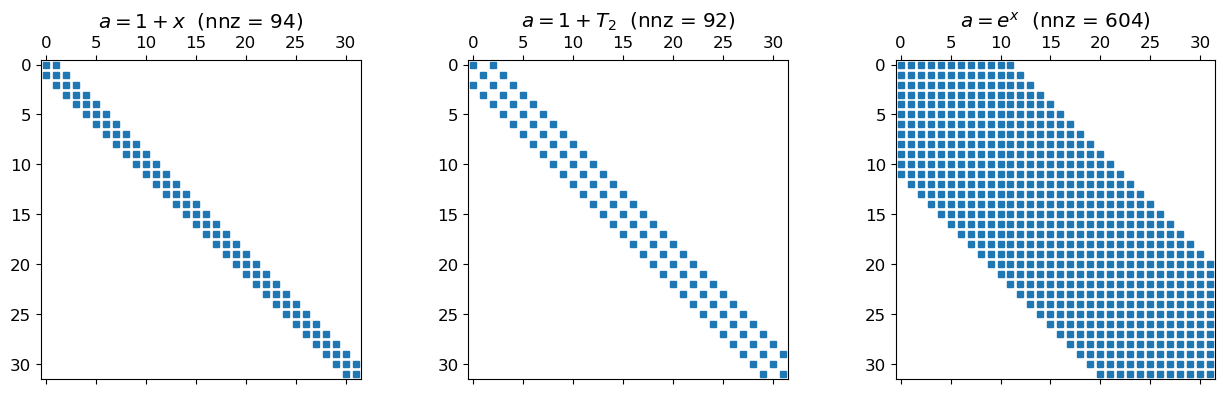

In [13]:
# Bandwidth picture: M_0[a] for three different a's of increasing degree.
N = 32
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

a_lin    = np.zeros(N + 1); a_lin[0] = 1; a_lin[1] = 1                    # 1 + x
a_quad   = np.zeros(N + 1); a_quad[0] = 1; a_quad[2] = 1                  # 1 + T_2
a_smooth = polyfit(np.exp(chebpts(N + 1)))                                # exp(x)

for ax, a_T, lbl in zip(axes,
                        [a_lin, a_quad, a_smooth],
                        [r'$a = 1 + x$', r'$a = 1 + T_2$', r'$a = e^x$']):
    M = M0_from_T(a_T, N)
    ax.spy(np.abs(M) > 1e-12, markersize=4)
    ax.set_title(lbl + f'  (nnz = {(np.abs(M) > 1e-12).sum()})')
plt.tight_layout(); plt.show()

Linear $a$ gives a tridiagonal. A degree-2 $a$ gives bandwidth two.
A non-polynomial but smooth $a$ produces something *full* in principle,
but its entries decay as fast as the Chebyshev coefficients of $a$,
which is to say very fast. In practice a reasonable truncation is
banded for all intents and purposes.

## 8. Worked example: $(1+x)\,u'(x) + u(x) = f(x),\ u(-1) = \alpha$

Now we put the multiplication operator to use. The $u$ term lives in
the $T$ basis, so we have to convert it into the $U$ basis with
$\mathcal{S}_0$ before adding it to the differentiated piece. The
interior of the operator is therefore
$$
\mathcal{M}_0[1+x]\,\mathcal{D}_0 + \mathcal{S}_0,
$$
both pieces of size $N \times (N+1)$. The boundary row sits on top.

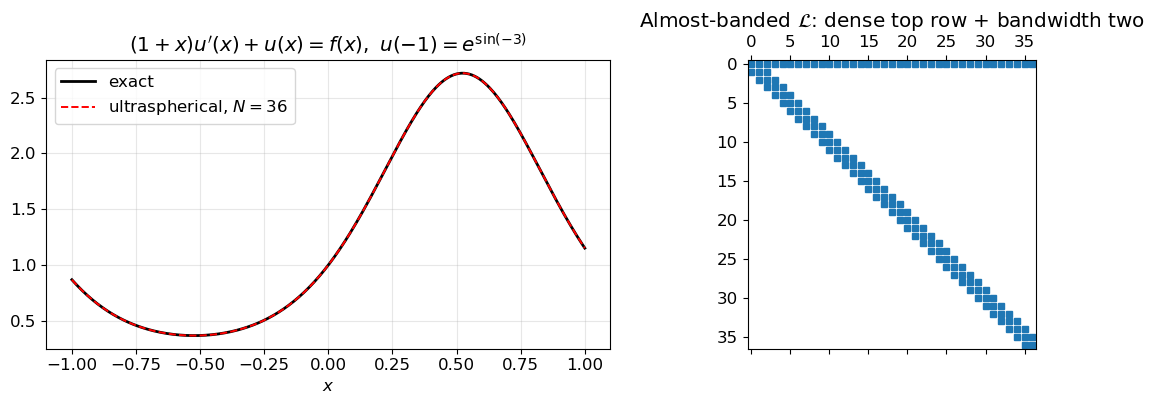

sup-norm error at N = 36: 1.29e-11


In [14]:
def assemble_var(N, a_T, f, alpha):
    # System for a(x) u'(x) + u(x) = f(x), u(-1) = alpha at length N+1.
    f_T = polyfit(f(chebpts(N + 1)))
    Ma = M0_from_T(a_T, N)
    interior = Ma @ D0(N) + S0(N)
    L = np.vstack([bc_left(N), interior])
    rhs = np.concatenate([[alpha], S0(N) @ f_T])
    return L, rhs


# Manufactured solution u(x) = exp(sin(3x)).
u_exact = lambda x: np.exp(np.sin(3 * x))
up_exact = lambda x: 3 * np.cos(3 * x) * np.exp(np.sin(3 * x))
f = lambda x: (1 + x) * up_exact(x) + u_exact(x)
alpha = u_exact(-1)

a_T_lin = lambda N: np.array([1.0, 1.0] + [0.0] * (N - 1))    # length N+1, a(x) = 1 + x

N = 36
L, rhs = assemble_var(N, a_T_lin(N), f, alpha)
c = np.linalg.solve(L, rhs)

xx = np.linspace(-1, 1, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(xx, u_exact(xx), 'k-', lw=2, label='exact')
axes[0].plot(xx, cheb_eval(c, xx), 'r--', lw=1.4, label=f'ultraspherical, $N = {N}$')
axes[0].set_xlabel('$x$'); axes[0].set_title(r"$(1+x)u'(x) + u(x) = f(x),\ u(-1) = e^{\sin(-3)}$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].spy(np.abs(L) > 1e-12, markersize=4)
axes[1].set_title('Almost-banded $\\mathcal{L}$: dense top row + bandwidth two')
plt.tight_layout(); plt.show()

print(f"sup-norm error at N = {N}: {np.max(np.abs(cheb_eval(c, xx) - u_exact(xx))):.2e}")

### Side-by-side convergence: $a = 1$ versus $a = 1 + x$

Both right-hand sides are smooth, so both should converge geometrically.
The variable-coefficient problem just costs slightly more work per
mode because the multiplication operator widens the band.

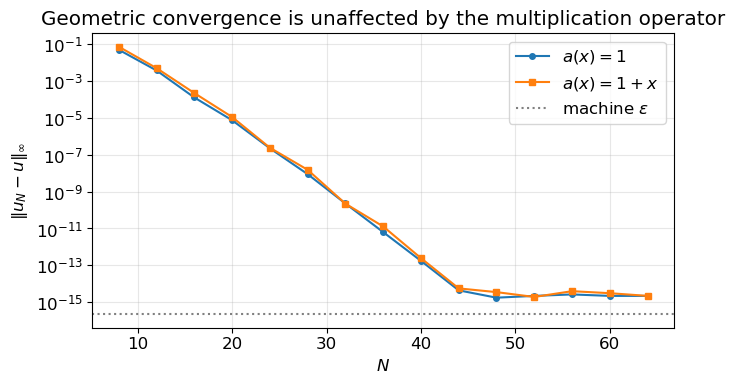

In [15]:
# Reuse the smooth manufactured solution. Compare the two a's.
u_exact_var = lambda x: np.exp(np.sin(3 * x))
up_var      = lambda x: 3 * np.cos(3 * x) * np.exp(np.sin(3 * x))

# Case A: a(x) = 1, equation u'(x) + u(x) = f(x).
fA = lambda x: up_var(x) + u_exact_var(x)
# Case B: a(x) = 1 + x, equation (1+x) u'(x) + u(x) = f(x).
fB = lambda x: (1 + x) * up_var(x) + u_exact_var(x)
alpha = u_exact_var(-1)

Ns = np.arange(8, 65, 4)
errs_A, errs_B = [], []
for N in Ns:
    a_const = np.zeros(N + 1); a_const[0] = 1.0
    LA, rA = assemble_var(N, a_const,    fA, alpha)
    LB, rB = assemble_var(N, a_T_lin(N), fB, alpha)
    cA = np.linalg.solve(LA, rA)
    cB = np.linalg.solve(LB, rB)
    errs_A.append(np.max(np.abs(cheb_eval(cA, xx) - u_exact_var(xx))))
    errs_B.append(np.max(np.abs(cheb_eval(cB, xx) - u_exact_var(xx))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(Ns, errs_A, 'o-', ms=4, label=r'$a(x) = 1$')
ax.semilogy(Ns, errs_B, 's-', ms=4, label=r'$a(x) = 1 + x$')
ax.axhline(np.finfo(float).eps, color='gray', ls=':', label='machine $\\varepsilon$')
ax.set_xlabel('$N$'); ax.set_ylabel(r'$\|u_N - u\|_\infty$')
ax.set_title('Geometric convergence is unaffected by the multiplication operator')
ax.legend(); ax.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

Both curves drop at the same geometric rate. The ultraspherical
formulation has done its job: a variable coefficient costs no
*accuracy*, only a wider band, and a wider band still gives a sparse
matrix.

## 9. Adaptive QR: choosing $N$ on the fly

Up to here we picked $N$ by hand. The *adaptive QR* algorithm
factors $\mathcal{L}$ column by column with Givens rotations and reads
off a free residual estimate after each column, stopping the moment
it drops below tolerance. The full derivation, including the residual
identity that makes this work, is in
[Adaptive QR](../interpolation/adaptive-qr.md). Here we just code it
up and watch it run.

### 9.1 Watching the QR sweep grow

Before running the solver, look at what the working matrix looks like
during the sweep. We process column $j$, apply Givens rotations to
zero entries below the diagonal, advance to column $j + 1$, repeat.

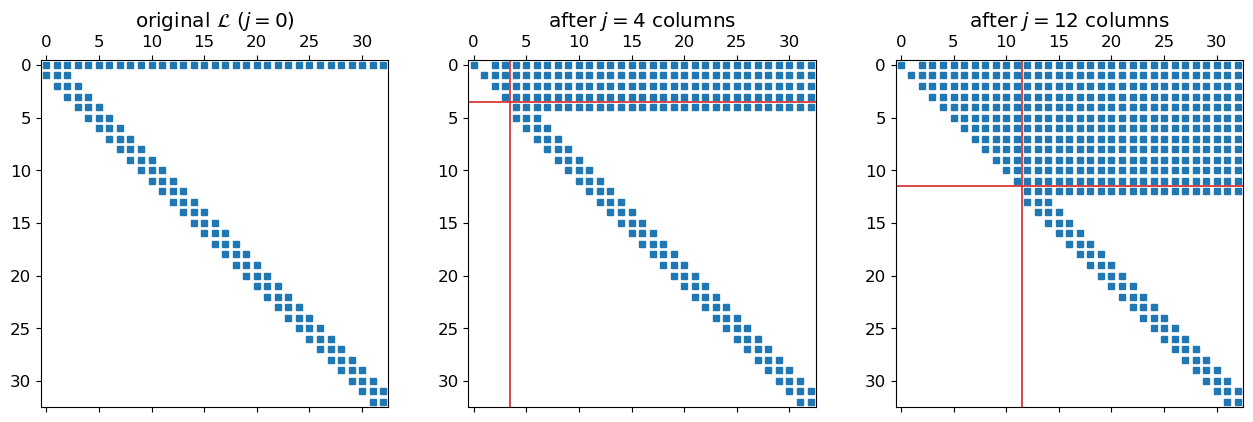

In [16]:
def incremental_qr_snapshots(L, snap_at):
    A = L.copy().astype(float)
    n = A.shape[0]
    snaps = {}
    for j in range(n):
        for i in range(n - 1, j, -1):
            a, b = A[j, j], A[i, j]
            if abs(b) < 1e-15: continue
            r = np.hypot(a, b); cs, sn = a / r, b / r
            new_j = cs * A[j, :] + sn * A[i, :]
            new_i = -sn * A[j, :] + cs * A[i, :]
            A[j, :], A[i, :] = new_j, new_i
        if (j + 1) in snap_at:
            snaps[j + 1] = A.copy()
    return snaps


# Build a representative L: the variable-coefficient operator from §8.
N_pic = 32
a_T_demo = np.zeros(N_pic + 1); a_T_demo[0] = 1.0; a_T_demo[1] = 1.0
L_pic, _ = assemble_var(N_pic, a_T_demo, lambda x: np.cos(3 * x), 0.0)
snaps = incremental_qr_snapshots(L_pic, snap_at=[4, 12])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (j, M), label in zip(axes,
                              [(0, L_pic), (4, snaps[4]), (12, snaps[12])],
                              ['original $\\mathcal{L}$ ($j = 0$)',
                               'after $j = 4$ columns',
                               'after $j = 12$ columns']):
    ax.spy(np.abs(M) > 1e-10, markersize=4)
    ax.set_title(label)
    if j > 0:
        ax.axhline(j - 0.5, color='C3', lw=1.2)
        ax.axvline(j - 0.5, color='C3', lw=1.2)
plt.tight_layout(); plt.show()

The upper-left triangle is the finished part $R_j$. Above the
diagonal the *processed* rows are dense: that is the dense boundary
row at row $0$ being rotated downward into rows $1, 2, \ldots$. **Below
the diagonal in unprocessed columns the band is preserved** and
that is what matters for cost. Each new column needs only a handful
of rotations, regardless of how far the sweep has progressed.

For a *purely* banded matrix (no dense top row) the bandwidth would be
preserved both above and below. The dense top row is the price we pay
for imposing one global boundary condition.

### 9.2 The adaptive solver

The algorithm is one loop: process column $j$ with Givens rotations,
evaluate the residual norm $\|\tilde{\mathbf{r}}_{j+1:}\|_2$ (which
[the chapter](../interpolation/adaptive-qr.md#thm-adaptive-qr-residual)
shows equals the residual of the truncated solve at size $j$), stop
when it drops below tolerance, back-solve the $R_j$ block.

In [17]:
def adaptive_qr_solve(L, rhs, tol=1e-12):
    # Adaptive QR for an almost-banded system. Stops when the residual norm
    # ||(Q_j^T r)_{j+1:}|| drops below tol. The residual is read for free
    # from the un-processed tail of the rotated right-hand side.
    R = L.copy().astype(float)
    bb = rhs.copy().astype(float)
    n = R.shape[0]
    history = []
    for j in range(n):
        # Triangularise column j: eliminate entries below the diagonal.
        for i in range(n - 1, j, -1):
            a, b = R[j, j], R[i, j]
            if abs(b) < 1e-15:
                continue
            r = np.hypot(a, b)
            cs, sn = a / r, b / r
            new_j = cs * R[j, :] + sn * R[i, :]
            new_i = -sn * R[j, :] + cs * R[i, :]
            R[j, :], R[i, :] = new_j, new_i
            new_bj = cs * bb[j] + sn * bb[i]
            new_bi = -sn * bb[j] + cs * bb[i]
            bb[j], bb[i] = new_bj, new_bi
        # Free residual estimate.
        res = float(np.linalg.norm(bb[j + 1:]))
        history.append(res)
        if res < tol and 1 <= j < n - 1:
            R_top = R[:j + 1, :j + 1]
            c = np.linalg.solve(R_top, bb[:j + 1])
            return c, {'N_opt': j, 'history': history, 'converged': True}
    c = np.linalg.solve(R[:n, :n], bb[:n])
    return c, {'N_opt': n - 1, 'history': history, 'converged': False}

### 9.3 Demo on a variable-coefficient BVP

Switch the coefficient to $a(x) = 2 + x$, which is bounded between
$1$ and $3$ on $[-1, 1]$ and does not vanish at the boundary. Then
the BVP

$$
(2 + x)\, u'(x) + u(x) = f(x), \qquad u(-1) = \alpha,
$$

is non-singular and we can pick any smooth $f$ and any $\alpha$ we
like. We use a moderately oscillatory right-hand side so the
resolution required is not obvious by inspection:
$f(x) = \cos(20 x) + \tfrac{1}{2}\,e^{\sin(5x)},\ \alpha = 0$.

adaptive QR converged: True,  N_opt = 58,  final residual = 8.78e-13


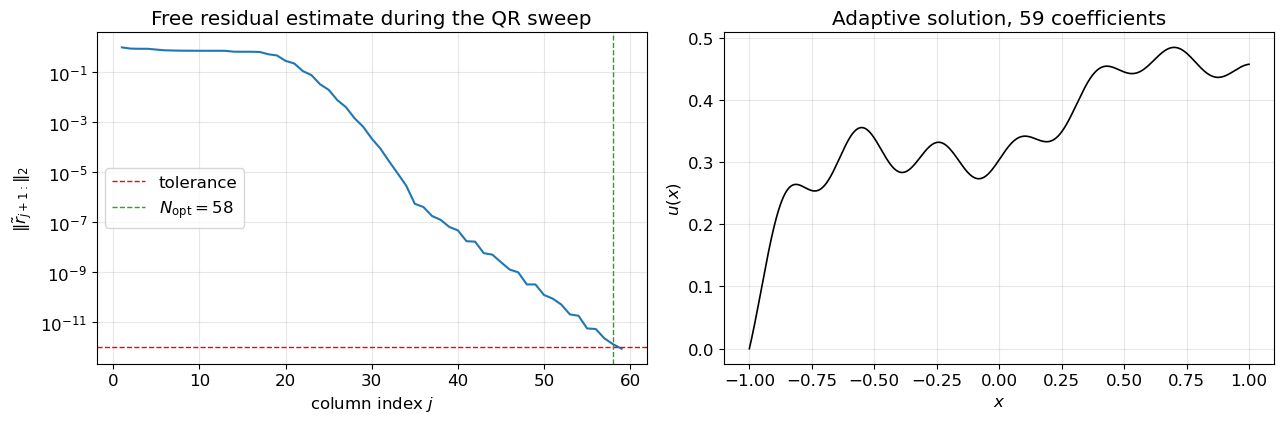

In [18]:
# Variable coefficient a(x) = 2 + x, T-coefficients (2, 1, 0, ...).
a_T_demo = lambda N: np.array([2.0, 1.0] + [0.0] * (N - 1))

f_demo = lambda x: np.cos(20 * x) + 0.5 * np.exp(np.sin(5 * x))
alpha  = 0.0

N_max = 120
L, rhs = assemble_var(N_max, a_T_demo(N_max), f_demo, alpha)
c, info = adaptive_qr_solve(L, rhs, tol=1e-12)
print(f"adaptive QR converged: {info['converged']},  N_opt = {info['N_opt']},  "
      f"final residual = {info['history'][-1]:.2e}")

# Plot residual history and the solution.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].semilogy(np.arange(1, len(info['history']) + 1), info['history'], '-')
axes[0].axhline(1e-12, color='r', ls='--', lw=1, label='tolerance')
axes[0].axvline(info['N_opt'], color='C2', ls='--', lw=1,
                label=f"$N_{{\\rm opt}} = {info['N_opt']}$")
axes[0].set_xlabel('column index $j$')
axes[0].set_ylabel(r'$\|\tilde{r}_{j+1:}\|_2$')
axes[0].set_title('Free residual estimate during the QR sweep')
axes[0].legend(); axes[0].grid(alpha=0.3, which='both')

xx = np.linspace(-1, 1, 1201)
axes[1].plot(xx, cheb_eval(c, xx), 'k-', lw=1.2)
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$u(x)$')
axes[1].set_title(f'Adaptive solution, {info["N_opt"] + 1} coefficients')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 9.4 Cross-check against a direct solve

Sanity test: the adaptive solve at $N_{\rm opt}$ should agree with a
plain $\mathtt{linalg.solve}$ at the same size, and a fresh solve at
$2 N_{\rm opt}$ should not change the answer (otherwise we picked
$N_{\rm opt}$ too small).

In [19]:
xx = np.linspace(-1, 1, 2001)

N1 = info['N_opt']
N2 = 2 * N1
L1, r1 = assemble_var(N1, a_T_demo(N1), f_demo, alpha)
L2, r2 = assemble_var(N2, a_T_demo(N2), f_demo, alpha)
c1 = np.linalg.solve(L1, r1)
c2 = np.linalg.solve(L2, r2)

print(f"||u_aqr - u_direct(N_opt)||_inf      = {np.max(np.abs(cheb_eval(c, xx) - cheb_eval(c1, xx))):.2e}")
print(f"||u_direct(N_opt) - u_direct(2N_opt)||_inf = {np.max(np.abs(cheb_eval(c1, xx) - cheb_eval(c2, xx))):.2e}")

||u_aqr - u_direct(N_opt)||_inf      = 7.88e-15
||u_direct(N_opt) - u_direct(2N_opt)||_inf = 2.16e-14
